In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
# Core Libraries
import os
import numpy as np
import pandas as pd
import random
import shutil
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

# TensorFlow & Keras
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import EfficientNetB5, EfficientNetB7, VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    EarlyStopping, 
    ReduceLROnPlateau, 
    ModelCheckpoint, 
    TensorBoard
)

# Image Processing & Augmentation
import cv2
from skimage import filters
import albumentations as A

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# System & GPU Optimization
from tensorflow.python.client import device_lib
import gc

# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Enable mixed-precision training for T4 GPU acceleration
tf.keras.mixed_precision.set_global_policy('mixed_float16')
print("Mixed precision enabled for GPU optimization.")

/usr/local/lib/python3.11/dist-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.5'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


Mixed precision enabled for GPU optimization.


In [3]:
# Define dataset paths
DATASET_DIR = "/kaggle/input/brain-tumor-dataset/Dataset"  # Update with your dataset path
CLASSES = ["meningioma", "glioma", "notumor", "pituitary"]
IMG_SIZE = (224, 224)  # Standard for EfficientNet & VGG16

# Define split ratios
TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
TEST_RATIO = 0.1

# Output directories for splits
SPLIT_DIR = "/kaggle/working/split_data"
os.makedirs(SPLIT_DIR, exist_ok=True)

In [4]:
def split_dataset(dataset_dir, output_dir, classes, train_ratio, val_ratio, test_ratio):
    """Stratified 80-10-10 split with persistence."""
    # Create directories
    os.makedirs(os.path.join(output_dir, "train"), exist_ok=True)
    os.makedirs(os.path.join(output_dir, "val"), exist_ok=True)
    os.makedirs(os.path.join(output_dir, "test"), exist_ok=True)
    
    for class_name in classes:
        # Get all images for the current class
        class_dir = os.path.join(dataset_dir, class_name)
        images = [f for f in os.listdir(class_dir) if f.endswith(('.jpg', '.png'))]
        
        # Split into train/val/test (stratified)
        train, temp = train_test_split(images, train_size=train_ratio, random_state=SEED)
        val, test = train_test_split(temp, test_size=test_ratio/(val_ratio + test_ratio), random_state=SEED)
        
        # Save splits
        def copy_files(files, split):
            dst_dir = os.path.join(output_dir, split, class_name)
            os.makedirs(dst_dir, exist_ok=True)
            for f in tqdm(files, desc=f"Copying {class_name} to {split}"):
                shutil.copy(os.path.join(class_dir, f), os.path.join(dst_dir, f))
        
        copy_files(train, "train")
        copy_files(val, "val")
        copy_files(test, "test")

# Execute splitting
split_dataset(DATASET_DIR, SPLIT_DIR, CLASSES, TRAIN_RATIO, VAL_RATIO, TEST_RATIO)
print("Dataset split completed and saved.")

Copying pituitary to test: 100%|██████████| 591/591 [00:04<00:00, 135.09it/s]

Dataset split completed and saved.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


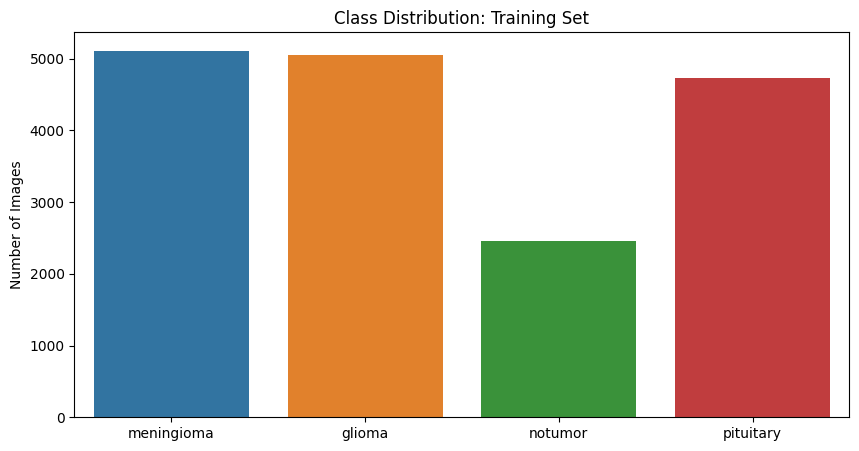

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


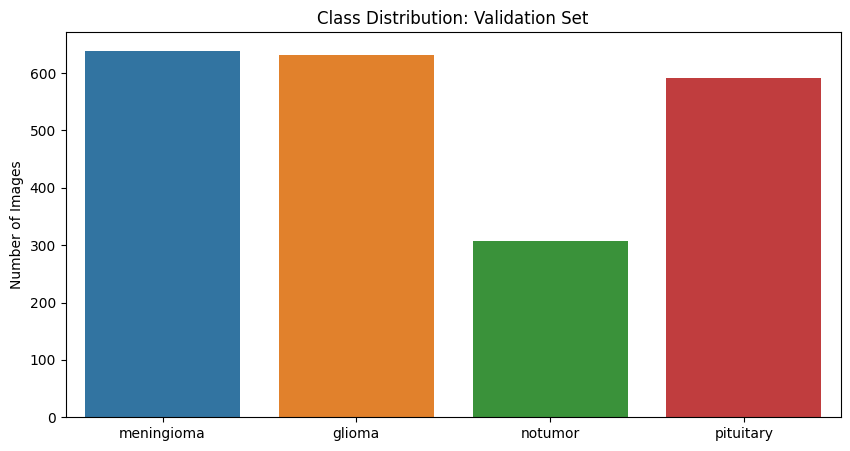

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


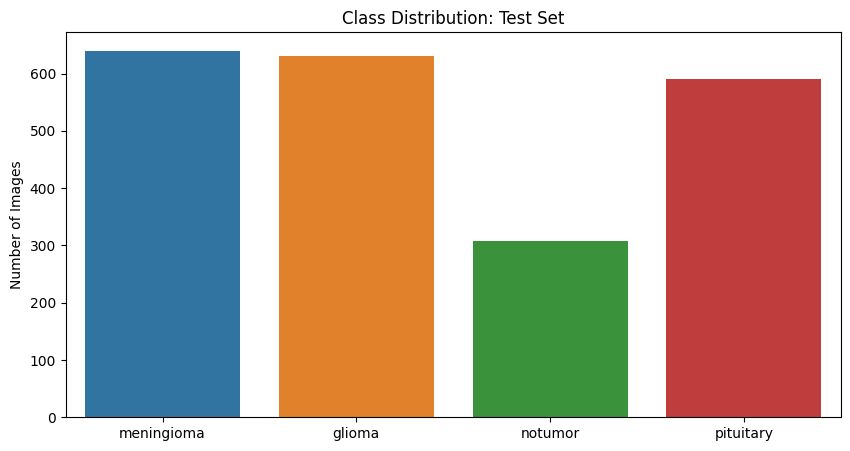


=== Dataset Summary ===
Training samples: 17335
Validation samples: 2168
Test samples: 2169


In [5]:
def plot_class_distribution(data_dir, title):
    """Visualize class distribution for a split."""
    counts = []
    for class_name in CLASSES:
        class_dir = os.path.join(data_dir, class_name)
        counts.append(len(os.listdir(class_dir)))
    
    plt.figure(figsize=(10, 5))
    sns.barplot(x=CLASSES, y=counts)
    plt.title(f"Class Distribution: {title}")
    plt.ylabel("Number of Images")
    plt.show()
    
    return counts

# Plot distributions
train_counts = plot_class_distribution(os.path.join(SPLIT_DIR, "train"), "Training Set")
val_counts = plot_class_distribution(os.path.join(SPLIT_DIR, "val"), "Validation Set")
test_counts = plot_class_distribution(os.path.join(SPLIT_DIR, "test"), "Test Set")

# Print summary
print("\n=== Dataset Summary ===")
print(f"Training samples: {sum(train_counts)}")
print(f"Validation samples: {sum(val_counts)}")
print(f"Test samples: {sum(test_counts)}")

In [6]:
# Custom preprocessing function (denoising + normalization)
def preprocess_image(image):
    """Professional-grade preprocessing pipeline (fixed for OpenCV compatibility)"""
    # Convert float image back to 8-bit for OpenCV operations
    if image.dtype != 'uint8':
        image = (image * 255).astype('uint8')
    
    # Denoising (now works with CV_8UC3)
    image = cv2.fastNlMeansDenoisingColored(image, None, 10, 10, 7, 21)
    
    # CLAHE
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    l = clahe.apply(l)
    lab = cv2.merge((l, a, b))
    image = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    
    # Normalize back to [0,1] for TensorFlow
    return image.astype('float32') / 255.0

# Albumentations for advanced augmentation
augmentation = A.Compose([
    A.Rotate(limit=45, p=0.5),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.GaussianBlur(blur_limit=(3, 7), p=0.2),
    A.RandomGamma(gamma_limit=(80, 120), p=0.3),
])

# Keras Data Generators
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_image,
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='reflect'
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_image)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_image)

In [7]:
# --- GPU Strategy Setup ---
try:
    # Detect if GPUs are available
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        # Enable memory growth and create MirroredStrategy
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        strategy = tf.distribute.MirroredStrategy()
        print(f"Using {strategy.num_replicas_in_sync} GPU(s)")
    else:
        strategy = tf.distribute.get_strategy()  # Default CPU strategy
        print("No GPUs found, using CPU")
except RuntimeError as e:
    print(f"Error setting up GPU strategy: {e}")
    strategy = tf.distribute.get_strategy()

# --- Data Generators ---
def create_generators(batch_size=32):
    train_gen = train_datagen.flow_from_directory(
        os.path.join(SPLIT_DIR, "train"),
        target_size=IMG_SIZE,
        batch_size=batch_size,
        class_mode='categorical',
        classes=CLASSES,
        shuffle=True,
        seed=SEED
    )
    
    val_gen = val_datagen.flow_from_directory(
        os.path.join(SPLIT_DIR, "val"),
        target_size=IMG_SIZE,
        batch_size=batch_size,
        class_mode='categorical',
        classes=CLASSES,
        shuffle=False
    )
    
    test_gen = test_datagen.flow_from_directory(
        os.path.join(SPLIT_DIR, "test"),
        target_size=IMG_SIZE,
        batch_size=batch_size,
        class_mode='categorical',
        classes=CLASSES,
        shuffle=False
    )
    
    # Calculate class weights
    class_weights = compute_class_weight(
        'balanced',
        classes=np.unique(train_gen.classes),
        y=train_gen.classes
    )
    class_weights = dict(enumerate(class_weights))
    
    print("\nClass weights:", class_weights)
    return train_gen, val_gen, test_gen, class_weights

# Initialize generators with batch size adapted to GPU count
BATCH_SIZE = 64 * strategy.num_replicas_in_sync  # Auto-scales with GPU count
print(f"\nUsing batch size: {BATCH_SIZE} (Adapted to {strategy.num_replicas_in_sync} GPU(s))")

train_gen, val_gen, test_gen, class_weights = create_generators(BATCH_SIZE)

I0000 00:00:1750063617.428587      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1750063617.429289      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Using 2 GPU(s)

Using batch size: 128 (Adapted to 2 GPU(s))
Found 17335 images belonging to 4 classes.
Found 2168 images belonging to 4 classes.
Found 2169 images belonging to 4 classes.

Class weights: {0: 0.8477601721439749, 1: 0.8590188305252725, 2: 1.7674347471451877, 3: 0.9170016927634363}


Found 17335 files belonging to 4 classes.
Found 2168 files belonging to 4 classes.
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/32


I0000 00:00:1749994995.300551     100 service.cc:148] XLA service 0x791f180066b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1749994995.301377     100 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1749994995.301396     100 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1749994995.702177     100 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-06-15 13:43:26.277478: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng11{k2=4,k3=0} for conv (f16[128,224,224,64]{3,2,1,0}, u8[0]{0}) custom-call(f16[128,224,224,64]{3,2,1,0}, f16[64,3,3,64]{3,2,1,0}, f16[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earlies

  1/136 ━━━━━━━━━━━━━━━━━━━━ 2:14:13 60s/step - accuracy: 0.2422 - loss: 5.1250

I0000 00:00:1749995037.271920     100 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - accuracy: 0.3315 - loss: 3.7376

2025-06-15 13:44:55.419288: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng11{k2=4,k3=0} for conv (f16[120,224,224,64]{3,2,1,0}, u8[0]{0}) custom-call(f16[120,224,224,64]{3,2,1,0}, f16[64,3,3,64]{3,2,1,0}, f16[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]} is taking a while...
2025-06-15 13:44:55.643701: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 1.224512406s
Trying algorithm eng11{k2=4,k3=0} for conv (f16[120,224,224,64]{3,2,1,0}, u8[0]{0}) custom-call(f16[120,224,224,64]{3,2,1,0}, f16[64,3,3,64]{3,2,1,0}, f16[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convBiasActivat

136/136 ━━━━━━━━━━━━━━━━━━━━ 147s 648ms/step - accuracy: 0.3320 - loss: 3.7305 - val_accuracy: 0.6541 - val_loss: 0.8913 - learning_rate: 1.0000e-04
Epoch 2/32
136/136 ━━━━━━━━━━━━━━━━━━━━ 27s 199ms/step - accuracy: 0.5772 - loss: 1.2877 - val_accuracy: 0.7315 - val_loss: 0.6943 - learning_rate: 1.0000e-04
Epoch 3/32
136/136 ━━━━━━━━━━━━━━━━━━━━ 27s 199ms/step - accuracy: 0.6540 - loss: 0.9099 - val_accuracy: 0.7601 - val_loss: 0.6182 - learning_rate: 1.0000e-04
Epoch 4/32
136/136 ━━━━━━━━━━━━━━━━━━━━ 27s 198ms/step - accuracy: 0.7012 - loss: 0.7664 - val_accuracy: 0.7887 - val_loss: 0.5669 - learning_rate: 1.0000e-04
Epoch 5/32
136/136 ━━━━━━━━━━━━━━━━━━━━ 27s 198ms/step - accuracy: 0.7346 - loss: 0.6855 - val_accuracy: 0.8067 - val_loss: 0.5225 - learning_rate: 1.0000e-04
Epoch 6/32
136/136 ━━━━━━━━━━━━━━━━━━━━ 27s 199ms/step - accuracy: 0.7595 - loss: 0.6287 - val_accuracy: 0.8155 - val_loss: 0.4920 - learning_rate: 1.0000e-04
Epoch 7/32
136/136 ━━━━━━━━━━━━━━━━━━━━ 27s 199ms/step -

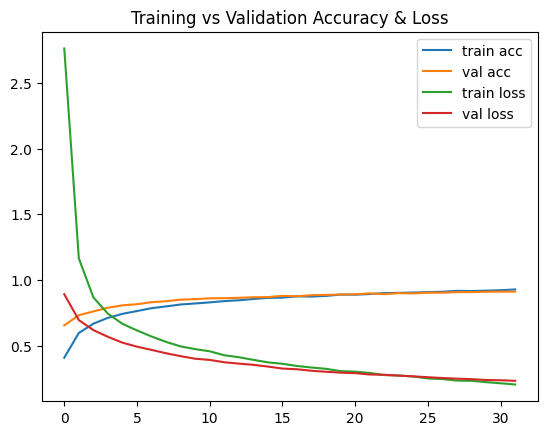

In [13]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

# Set paths
train_dir = "/kaggle/working/split_data/train"
val_dir = "/kaggle/working/split_data/val"
img_size = (224, 224)
batch_size = 128
num_classes = 4

# Load datasets
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical"  # Ensures one-hot encoded labels
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical"
)

# Prefetch and cache
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# VGG16 base model
base_model = VGG16(include_top=False, input_shape=(224, 224, 3), weights="imagenet")
base_model.trainable = False  # Freeze convolutional layers

# Build the model
inputs = layers.Input(shape=(224, 224, 3))
x = tf.keras.applications.vgg16.preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)

# Compile
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks

checkpoint_cb = ModelCheckpoint("vgg16_best_model.h5", save_best_only=True, monitor='val_accuracy', mode='max')
earlystop_cb = EarlyStopping(patience=5, restore_best_weights=True)
reduce_lr_cb = ReduceLROnPlateau(factor=0.5, patience=3, verbose=1)

# Train
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=32,
    callbacks=[checkpoint_cb, earlystop_cb, reduce_lr_cb]
)

# Plot training results
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Training vs Validation Accuracy & Loss")
plt.show()


In [14]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam

# Constants
img_size = (224, 224)
batch_size = 128
num_classes = 4

# Load test dataset
test_dir = "/kaggle/working/split_data/test"
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical"
).cache().prefetch(buffer_size=tf.data.AUTOTUNE)

# Rebuild the model architecture (must match training exactly)
base_model = VGG16(include_top=False, input_shape=(224, 224, 3), weights="imagenet")
base_model.trainable = False

inputs = layers.Input(shape=(224, 224, 3))
x = tf.keras.applications.vgg16.preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ✅ Load weights only
model.load_weights("vgg16_best_model.h5")

# ✅ Evaluate
print("Evaluating the model on the test set...")
loss, accuracy = model.evaluate(test_ds, verbose=1)
print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")


Found 2169 files belonging to 4 classes.
Evaluating the model on the test set...
16/17 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.9096 - loss: 0.2362

2025-06-15 14:01:18.859253: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng11{k2=4,k3=0} for conv (f16[121,224,224,64]{3,2,1,0}, u8[0]{0}) custom-call(f16[121,224,224,64]{3,2,1,0}, f16[64,3,3,64]{3,2,1,0}, f16[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]} is taking a while...
2025-06-15 14:01:19.091019: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 1.231867084s
Trying algorithm eng11{k2=4,k3=0} for conv (f16[121,224,224,64]{3,2,1,0}, u8[0]{0}) custom-call(f16[121,224,224,64]{3,2,1,0}, f16[64,3,3,64]{3,2,1,0}, f16[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convBiasActivat

17/17 ━━━━━━━━━━━━━━━━━━━━ 45s 3s/step - accuracy: 0.9107 - loss: 0.2338 

Test Loss: 0.2150
Test Accuracy: 0.9189


Found 17335 files belonging to 4 classes.
Found 2168 files belonging to 4 classes.
115263384/115263384 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/32
136/136 ━━━━━━━━━━━━━━━━━━━━ 161s 648ms/step - accuracy: 0.5187 - loss: 1.1016 - val_accuracy: 0.7408 - val_loss: 0.6772 - learning_rate: 1.0000e-04
Epoch 2/32
136/136 ━━━━━━━━━━━━━━━━━━━━ 30s 220ms/step - accuracy: 0.7463 - loss: 0.6704 - val_accuracy: 0.7892 - val_loss: 0.5548 - learning_rate: 1.0000e-04
Epoch 3/32
136/136 ━━━━━━━━━━━━━━━━━━━━ 29s 215ms/step - accuracy: 0.7889 - loss: 0.5715 - val_accuracy: 0.8169 - val_loss: 0.5015 - learning_rate: 1.0000e-04
Epoch 4/32
136/136 ━━━━━━━━━━━━━━━━━━━━ 29s 215ms/step - accuracy: 0.8113 - loss: 0.5150 - val_accuracy: 0.8284 - val_loss: 0.4586 - learning_rate: 1.0000e-04
Epoch 5/32
136/136 ━━━━━━━━━━━━━━━━━━━━ 29s 216ms/step - accuracy: 0.8309 - loss: 0.4664 - val_accuracy: 0.8376 - val_loss: 0.4302 - learning_rate: 1.0000e-04
Epoch 6/32
136/136 ━━━━━━━━━━━━━━━━━━━━ 29s 215ms/step - accuracy: 0

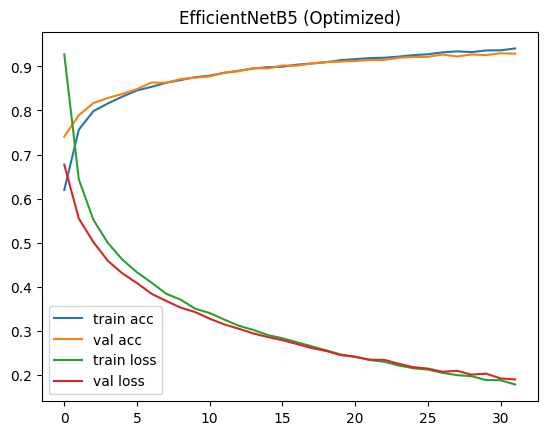

In [15]:

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB5
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

# Set image size to smaller resolution
# Set paths
train_dir = "/kaggle/working/split_data/train"
val_dir = "/kaggle/working/split_data/val"
img_size = (224, 224)
batch_size = 128
num_classes = 4   # Reduced from 32

# Load datasets
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir, image_size=img_size, batch_size=batch_size, label_mode="categorical"
)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir, image_size=img_size, batch_size=batch_size, label_mode="categorical"
)

# Optimize pipeline
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(500).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# Load base model
base_model = EfficientNetB5(include_top=False, input_shape=(224, 224, 3), weights='imagenet')
base_model.trainable = False

# Build model
inputs = layers.Input(shape=(224, 224, 3))
x = tf.keras.applications.efficientnet.preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)  # reduced neurons
x = layers.Dropout(0.3)(x)  # slightly lower dropout
outputs = layers.Dense(num_classes, activation='softmax')(x)
model = models.Model(inputs, outputs)

# Compile
model.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

# Callbacks
checkpoint_cb = ModelCheckpoint("effnetb5_best_model.h5", save_best_only=True, monitor='val_accuracy', mode='max')
earlystop_cb = EarlyStopping(patience=4, restore_best_weights=True)
reduce_lr_cb = ReduceLROnPlateau(factor=0.5, patience=2, verbose=1)

# Train
history = model.fit(
    train_ds, validation_data=val_ds, epochs=32,  # Reduced epochs
    callbacks=[checkpoint_cb, earlystop_cb, reduce_lr_cb]
)

# Plot
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title("EfficientNetB5 (Optimized)")
plt.show()


In [16]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB5
from tensorflow.keras.optimizers import Adam

# Constants
img_size = (224, 224)
batch_size = 128
num_classes = 4

# Load test dataset
test_dir = "/kaggle/working/split_data/test"
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical"
).cache().prefetch(buffer_size=tf.data.AUTOTUNE)

# Rebuild the model architecture (must match training exactly)
base_model = EfficientNetB5(include_top=False, input_shape=(224, 224, 3), weights='imagenet')
base_model.trainable = False

inputs = layers.Input(shape=(224, 224, 3))
x = tf.keras.applications.efficientnet.preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ✅ Load weights only
model.load_weights("effnetb5_best_model.h5")

# ✅ Evaluate
print("Evaluating EfficientNetB5 model on the test set...")
loss, accuracy = model.evaluate(test_ds, verbose=1)
print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")


Found 2169 files belonging to 4 classes.
Evaluating EfficientNetB5 model on the test set...
17/17 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.9518 - loss: 0.1669 

Test Loss: 0.1641
Test Accuracy: 0.9530


Found 2169 files belonging to 4 classes.
Evaluating EfficientNetB5 model on the test set...
17/17 ━━━━━━━━━━━━━━━━━━━━ 32s 590ms/step - accuracy: 0.9483 - loss: 0.1824

✅ Test Loss: 0.1641
✅ Test Accuracy: 0.9530
17/17 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step 


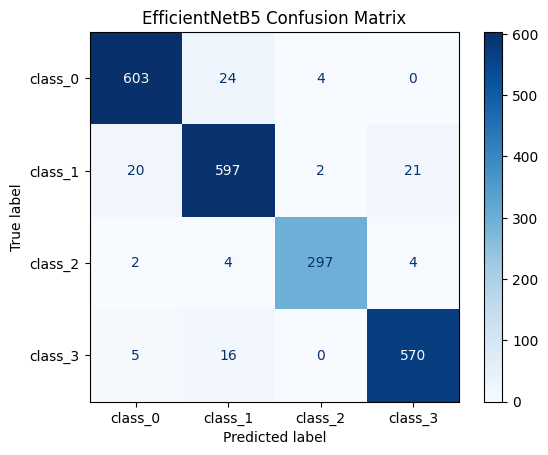


Classification Report:
              precision    recall  f1-score   support

     class_0       0.96      0.96      0.96       631
     class_1       0.93      0.93      0.93       640
     class_2       0.98      0.97      0.97       307
     class_3       0.96      0.96      0.96       591

    accuracy                           0.95      2169
   macro avg       0.96      0.96      0.96      2169
weighted avg       0.95      0.95      0.95      2169



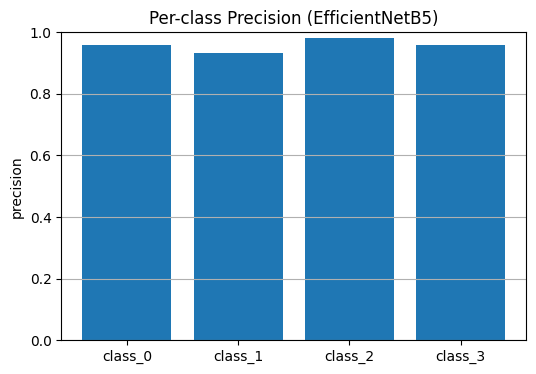

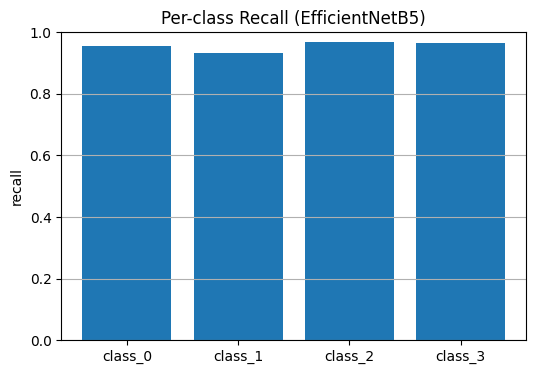

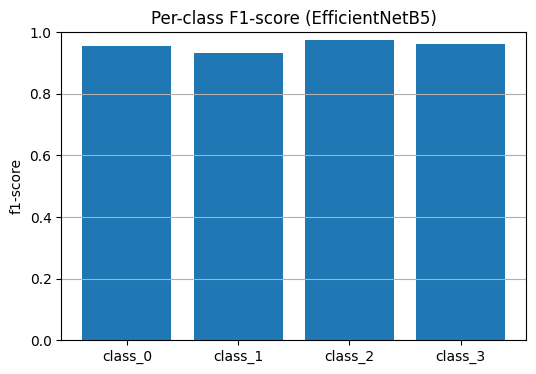

In [19]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB5
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Constants
img_size = (224, 224)
batch_size = 128
num_classes = 4
class_names = ['class_0', 'class_1', 'class_2', 'class_3']  # Update with actual class names if needed

# Load test dataset
test_dir = "/kaggle/working/split_data/test"
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical",
    shuffle=False  # Important for matching predictions with labels
)

test_ds = test_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

# Rebuild model
base_model = EfficientNetB5(include_top=False, input_shape=(224, 224, 3), weights='imagenet')
base_model.trainable = False

inputs = layers.Input(shape=(224, 224, 3))
x = tf.keras.applications.efficientnet.preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)

# Compile
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

# Load weights
model.load_weights("effnetb5_best_model.h5")

# Evaluate
print("Evaluating EfficientNetB5 model on the test set...")
loss, accuracy = model.evaluate(test_ds, verbose=1)
print(f"\n✅ Test Loss: {loss:.4f}")
print(f"✅ Test Accuracy: {accuracy:.4f}")

# Get predictions
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# Get true labels
y_true = np.concatenate([np.argmax(y, axis=1) for x, y in test_ds], axis=0)

# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(conf_matrix, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("EfficientNetB5 Confusion Matrix")
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Optional: Bar chart of accuracy per class
report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
metrics = ['precision', 'recall', 'f1-score']

for metric in metrics:
    plt.figure(figsize=(6,4))
    plt.bar(class_names, [report[c][metric] for c in class_names])
    plt.title(f"Per-class {metric.capitalize()} (EfficientNetB5)")
    plt.ylabel(metric)
    plt.ylim(0, 1)
    plt.grid(axis='y')
    plt.show()


Found 17335 files belonging to 4 classes.
Found 2168 files belonging to 4 classes.
258076736/258076736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/100


I0000 00:00:1750063768.997998     101 service.cc:148] XLA service 0x79eef40019a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1750063768.998953     101 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1750063768.998973     101 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1750063775.567544     101 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1750063815.562753     101 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


136/136 ━━━━━━━━━━━━━━━━━━━━ 256s 1s/step - accuracy: 0.5295 - loss: 1.0664 - val_accuracy: 0.7726 - val_loss: 0.6049 - learning_rate: 1.0000e-04
Epoch 2/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 62s 455ms/step - accuracy: 0.7699 - loss: 0.6072 - val_accuracy: 0.8137 - val_loss: 0.4901 - learning_rate: 1.0000e-04
Epoch 3/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 62s 453ms/step - accuracy: 0.8185 - loss: 0.5009 - val_accuracy: 0.8395 - val_loss: 0.4396 - learning_rate: 1.0000e-04
Epoch 4/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 60s 445ms/step - accuracy: 0.8350 - loss: 0.4552 - val_accuracy: 0.8510 - val_loss: 0.4069 - learning_rate: 1.0000e-04
Epoch 5/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 60s 444ms/step - accuracy: 0.8442 - loss: 0.4271 - val_accuracy: 0.8612 - val_loss: 0.3748 - learning_rate: 1.0000e-04
Epoch 6/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 61s 447ms/step - accuracy: 0.8590 - loss: 0.3916 - val_accuracy: 0.8741 - val_loss: 0.3561 - learning_rate: 1.0000e-04
Epoch 7/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 61s 447ms/ste

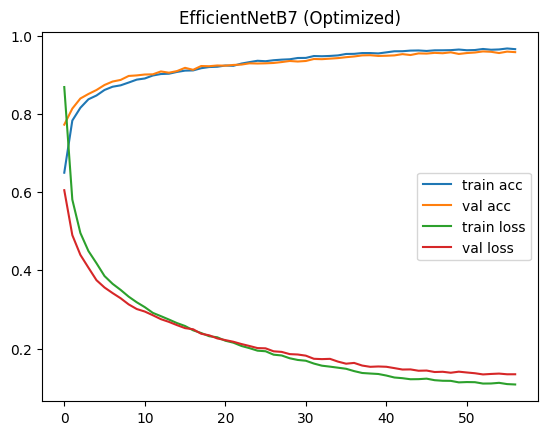

In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB7
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

# Set image size to smaller resolution
# Set paths
train_dir = "/kaggle/working/split_data/train"
val_dir = "/kaggle/working/split_data/val"
img_size = (224, 224)
batch_size = 128
num_classes = 4   # Reduced from 32

# Load datasets
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir, image_size=img_size, batch_size=batch_size, label_mode="categorical"
)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir, image_size=img_size, batch_size=batch_size, label_mode="categorical"
)

# Optimize pipeline
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(500).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# Load base model
base_model = EfficientNetB7(include_top=False, input_shape=(224, 224, 3), weights='imagenet')
base_model.trainable = False

# Build model
inputs = layers.Input(shape=(224, 224, 3))
x = tf.keras.applications.efficientnet.preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)  # reduced neurons
x = layers.Dropout(0.3)(x)  # slightly lower dropout
outputs = layers.Dense(num_classes, activation='softmax')(x)
model = models.Model(inputs, outputs)

# Compile
model.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

# Callbacks
checkpoint_cb = ModelCheckpoint("effnetb7_perfect_model.h5", save_best_only=True, monitor='val_accuracy', mode='max')
earlystop_cb = EarlyStopping(patience=4, restore_best_weights=True)
reduce_lr_cb = ReduceLROnPlateau(factor=0.5, patience=2, verbose=1)

# Train
history = model.fit(
    train_ds, validation_data=val_ds, epochs=100,  # Reduced epochs
    callbacks=[checkpoint_cb, earlystop_cb, reduce_lr_cb]
)

# Plot
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title("EfficientNetB7 (Optimized)")
plt.show()


In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB7
from tensorflow.keras.optimizers import Adam

# Constants
img_size = (224, 224)
batch_size = 128
num_classes = 4

# Load test dataset
test_dir = "/kaggle/working/split_data/test"
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical"
).cache().prefetch(buffer_size=tf.data.AUTOTUNE)

# Rebuild the model architecture (must match training exactly)
base_model = EfficientNetB7(include_top=False, input_shape=(224, 224, 3), weights='imagenet')
base_model.trainable = False

inputs = layers.Input(shape=(224, 224, 3))
x = tf.keras.applications.efficientnet.preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ✅ Load weights only
model.load_weights("effnetb7_perfect_model.h5")

# ✅ Evaluate
print("Evaluating EfficientNetB7 model on the test set...")
loss, accuracy = model.evaluate(test_ds, verbose=1)
print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")


Found 2169 files belonging to 4 classes.
Evaluating EfficientNetB7 model on the test set...
17/17 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.9662 - loss: 0.1121 

Test Loss: 0.1128
Test Accuracy: 0.9659


Found 2169 files belonging to 4 classes.
Evaluating EfficientNetB5 model on the test set...
17/17 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step - accuracy: 0.9574 - loss: 0.1374 

✅ Test Loss: 0.1133
✅ Test Accuracy: 0.9650
17/17 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step 


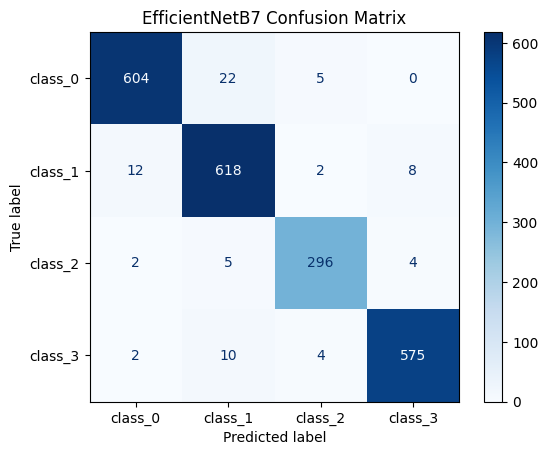


Classification Report:
              precision    recall  f1-score   support

     class_0       0.97      0.96      0.97       631
     class_1       0.94      0.97      0.95       640
     class_2       0.96      0.96      0.96       307
     class_3       0.98      0.97      0.98       591

    accuracy                           0.96      2169
   macro avg       0.97      0.96      0.97      2169
weighted avg       0.97      0.96      0.97      2169



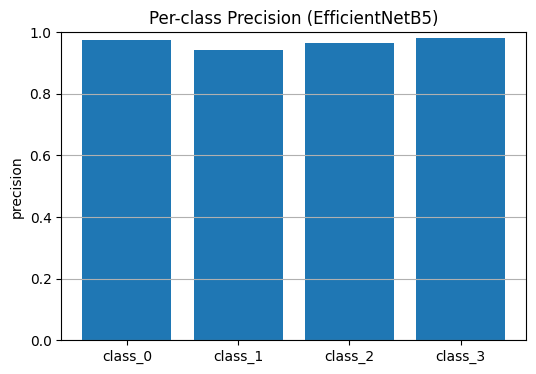

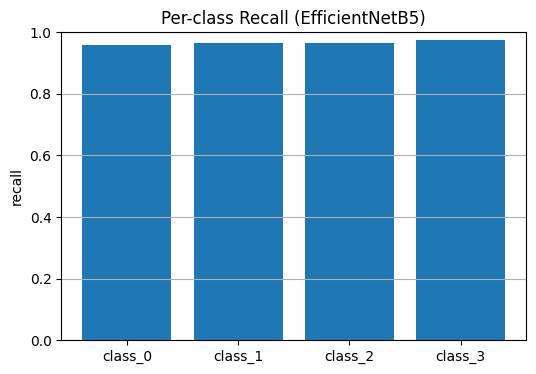

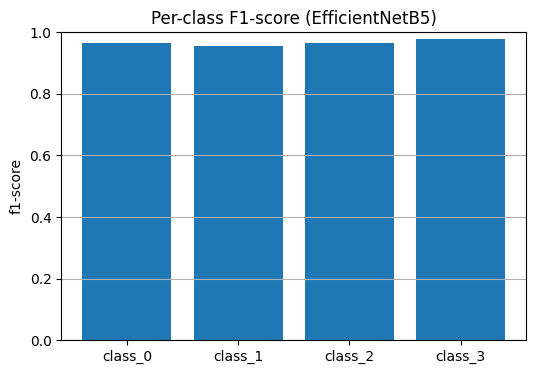

In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB7
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Constants
img_size = (224, 224)
batch_size = 128
num_classes = 4
class_names = ['class_0', 'class_1', 'class_2', 'class_3']  # Update with actual class names if needed

# Load test dataset
test_dir = "/kaggle/working/split_data/test"
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical",
    shuffle=False  # Important for matching predictions with labels
)

test_ds = test_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

# Rebuild model
base_model = EfficientNetB7(include_top=False, input_shape=(224, 224, 3), weights='imagenet')
base_model.trainable = False

inputs = layers.Input(shape=(224, 224, 3))
x = tf.keras.applications.efficientnet.preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)

# Compile
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

# Load weights
model.load_weights("effnetb7_perfect_model.h5")

# Evaluate
print("Evaluating EfficientNetB5 model on the test set...")
loss, accuracy = model.evaluate(test_ds, verbose=1)
print(f"\n✅ Test Loss: {loss:.4f}")
print(f"✅ Test Accuracy: {accuracy:.4f}")

# Get predictions
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# Get true labels
y_true = np.concatenate([np.argmax(y, axis=1) for x, y in test_ds], axis=0)

# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(conf_matrix, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("EfficientNetB7 Confusion Matrix")
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Optional: Bar chart of accuracy per class
report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
metrics = ['precision', 'recall', 'f1-score']

for metric in metrics:
    plt.figure(figsize=(6,4))
    plt.bar(class_names, [report[c][metric] for c in class_names])
    plt.title(f"Per-class {metric.capitalize()} (EfficientNetB5)")
    plt.ylabel(metric)
    plt.ylim(0, 1)
    plt.grid(axis='y')
    plt.show()


In [9]:
import os
from IPython.display import FileLink

# Name of the file to download
file_name = 'effnetb7_perfect_model.h5'

try:
    # Create a download link in the notebook
    display(FileLink(file_name))
    print(f"Click the link above to download '{file_name}'")
except FileNotFoundError:
    print(f"Error: File '{file_name}' not found in the current directory.")
except Exception as e:
    print(f"An error occurred: {e}")

/kaggle/working/effnetb7_perfect_model.h5

Click the link above to download 'effnetb7_perfect_model.h5'


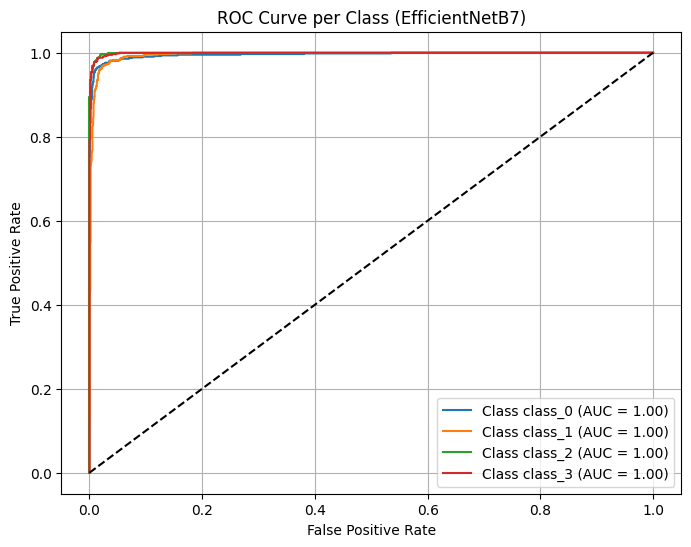

In [11]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize true labels
y_true_bin = label_binarize(y_true, classes=[0, 1, 2, 3])

# Compute ROC and AUC for each class
plt.figure(figsize=(8,6))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve per Class (EfficientNetB7)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid()
plt.show()


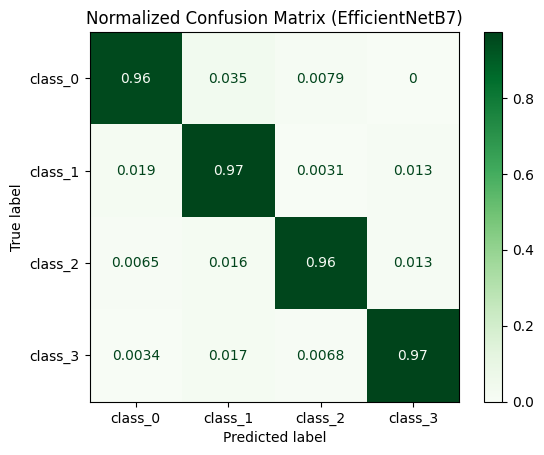

In [12]:
# Normalize the confusion matrix
conf_matrix_norm = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]
disp = ConfusionMatrixDisplay(conf_matrix_norm, display_labels=class_names)
disp.plot(cmap=plt.cm.Greens)
plt.title("Normalized Confusion Matrix (EfficientNetB7)")
plt.show()


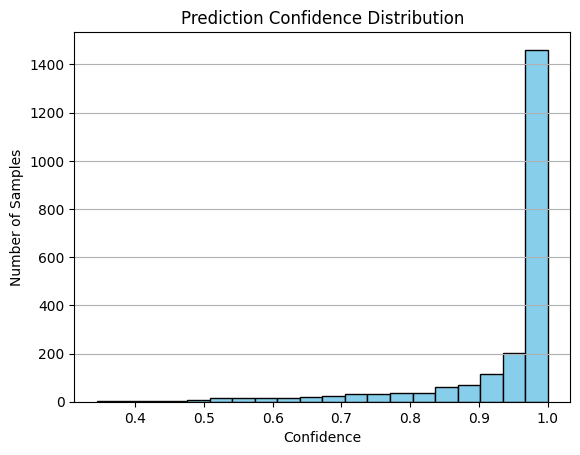

In [14]:
confidences = np.max(y_pred_probs, axis=1)
plt.hist(confidences, bins=20, color='skyblue', edgecolor='black')
plt.title("Prediction Confidence Distribution")
plt.xlabel("Confidence")
plt.ylabel("Number of Samples")
plt.grid(axis='y')
plt.show()


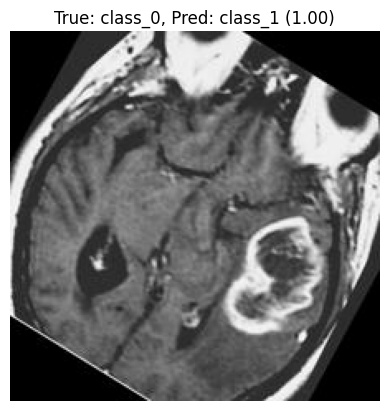

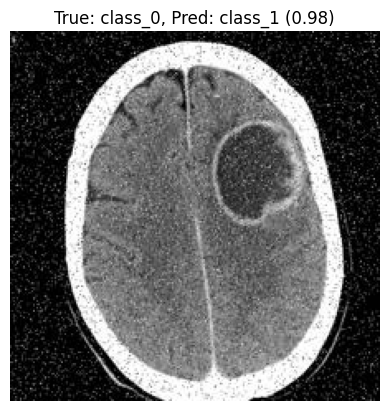

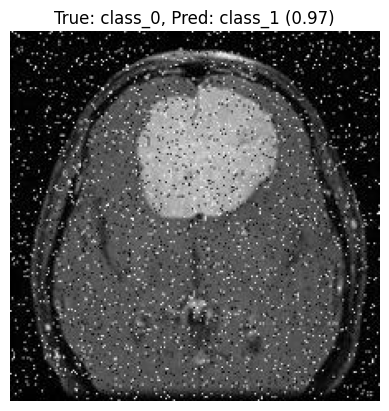

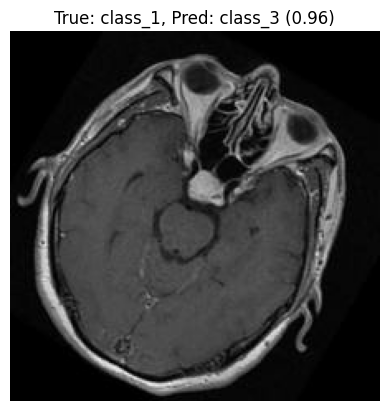

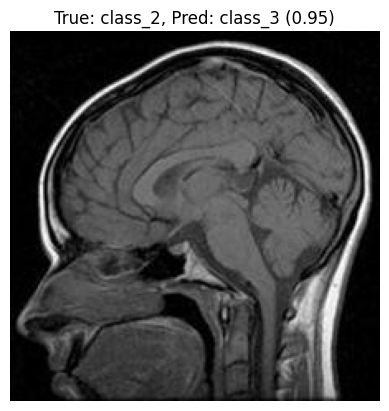

In [15]:
wrong_idxs = np.where(y_pred != y_true)[0]
wrong_confidences = confidences[wrong_idxs]
top_wrong_idxs = wrong_idxs[np.argsort(-wrong_confidences)[:5]]

for i in top_wrong_idxs:
    image_batch = list(test_ds.unbatch().as_numpy_iterator())[i][0].astype("uint8")
    plt.imshow(image_batch)
    plt.title(f"True: {class_names[y_true[i]]}, Pred: {class_names[y_pred[i]]} ({confidences[i]:.2f})")
    plt.axis("off")
    plt.show()


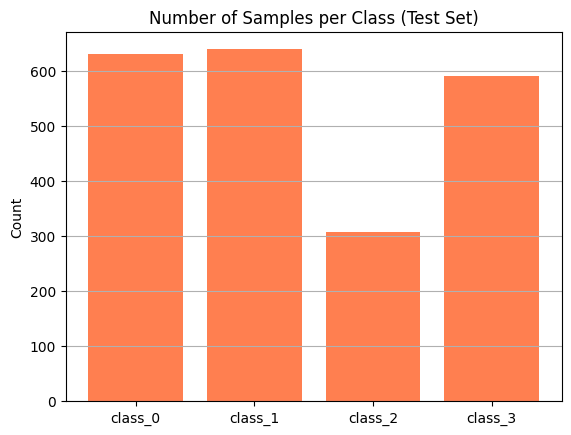

In [16]:
from collections import Counter

support_counts = Counter(y_true)
plt.bar(class_names, [support_counts[i] for i in range(num_classes)], color='coral')
plt.title("Number of Samples per Class (Test Set)")
plt.ylabel("Count")
plt.grid(axis='y')
plt.show()


In [17]:
import pandas as pd

summary_df = pd.DataFrame(report).transpose()
display(summary_df.round(3))


,precision,recall,f1-score,support
class_0,0.974,0.957,0.966,631.000
class_1,0.944,0.966,0.954,640.000
class_2,0.964,0.964,0.964,307.000
class_3,0.980,0.973,0.976,591.000
accuracy,0.965,0.965,0.965,0.965
macro avg,0.965,0.965,0.965,2169.000
weighted avg,0.965,0.965,0.965,2169.000
